<a href="https://colab.research.google.com/github/Safia-Rasheed-749/ML/blob/main/MultipleLR_Assmnt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
import pandas as pd
from sklearn import linear_model
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error
import seaborn as sns
import matplotlib.pyplot as plt


In [5]:
df = pd.read_csv("/content/drive/MyDrive/MLDATASETS/Fish[1].csv")
df
# Note: The line 'x-train,y-train,x-test,y-test = train_test_split(x,y,test_size=0.2,random_state=42)'
# caused a SyntaxError because Python interprets 'x-train' as 'x' minus 'train'.
# Variable names should use underscores, like 'x_train'.
# Also, ensure you import 'train_test_split' from 'sklearn.model_selection'.

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340
...,...,...,...,...,...,...,...
154,Smelt,12.2,11.5,12.2,13.4,2.0904,1.3936
155,Smelt,13.4,11.7,12.4,13.5,2.4300,1.2690
156,Smelt,12.2,12.1,13.0,13.8,2.2770,1.2558
157,Smelt,19.7,13.2,14.3,15.2,2.8728,2.0672


In [6]:
# Exploratory data Analysis
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Species  159 non-null    object 
 1   Weight   159 non-null    float64
 2   Length1  159 non-null    float64
 3   Length2  159 non-null    float64
 4   Length3  159 non-null    float64
 5   Height   159 non-null    float64
 6   Width    159 non-null    float64
dtypes: float64(6), object(1)
memory usage: 8.8+ KB


In [7]:
df.isnull().sum()

,0
Species,0
Weight,0
Length1,0
Length2,0
Length3,0
Height,0
Width,0


In [8]:
df.value_counts()

Species    Weight  Length1  Length2  Length3  Height   Width 
Bream      242.0   23.2     25.4     30.0     11.5200  4.0200    1
           290.0   24.0     26.3     31.2     12.4800  4.3056    1
           340.0   23.9     26.5     31.1     12.3778  4.6961    1
                   29.5     32.0     37.3     13.9129  5.0728    1
           363.0   26.3     29.0     33.5     12.7300  4.4555    1
                                                                ..
Whitefish  270.0   24.1     26.5     29.3     8.1454   4.2485    1
           306.0   25.6     28.0     30.8     8.7780   4.6816    1
           540.0   28.5     31.0     34.0     10.7440  6.5620    1
           800.0   33.7     36.4     39.6     11.7612  6.5736    1
           1000.0  37.3     40.0     43.5     12.3540  6.5250    1
Name: count, Length: 159, dtype: int64

In [9]:
df.Species.value_counts()

,count
Species,
Perch,56
Bream,35
Roach,20
Pike,17
Smelt,14
Parkki,11
Whitefish,6


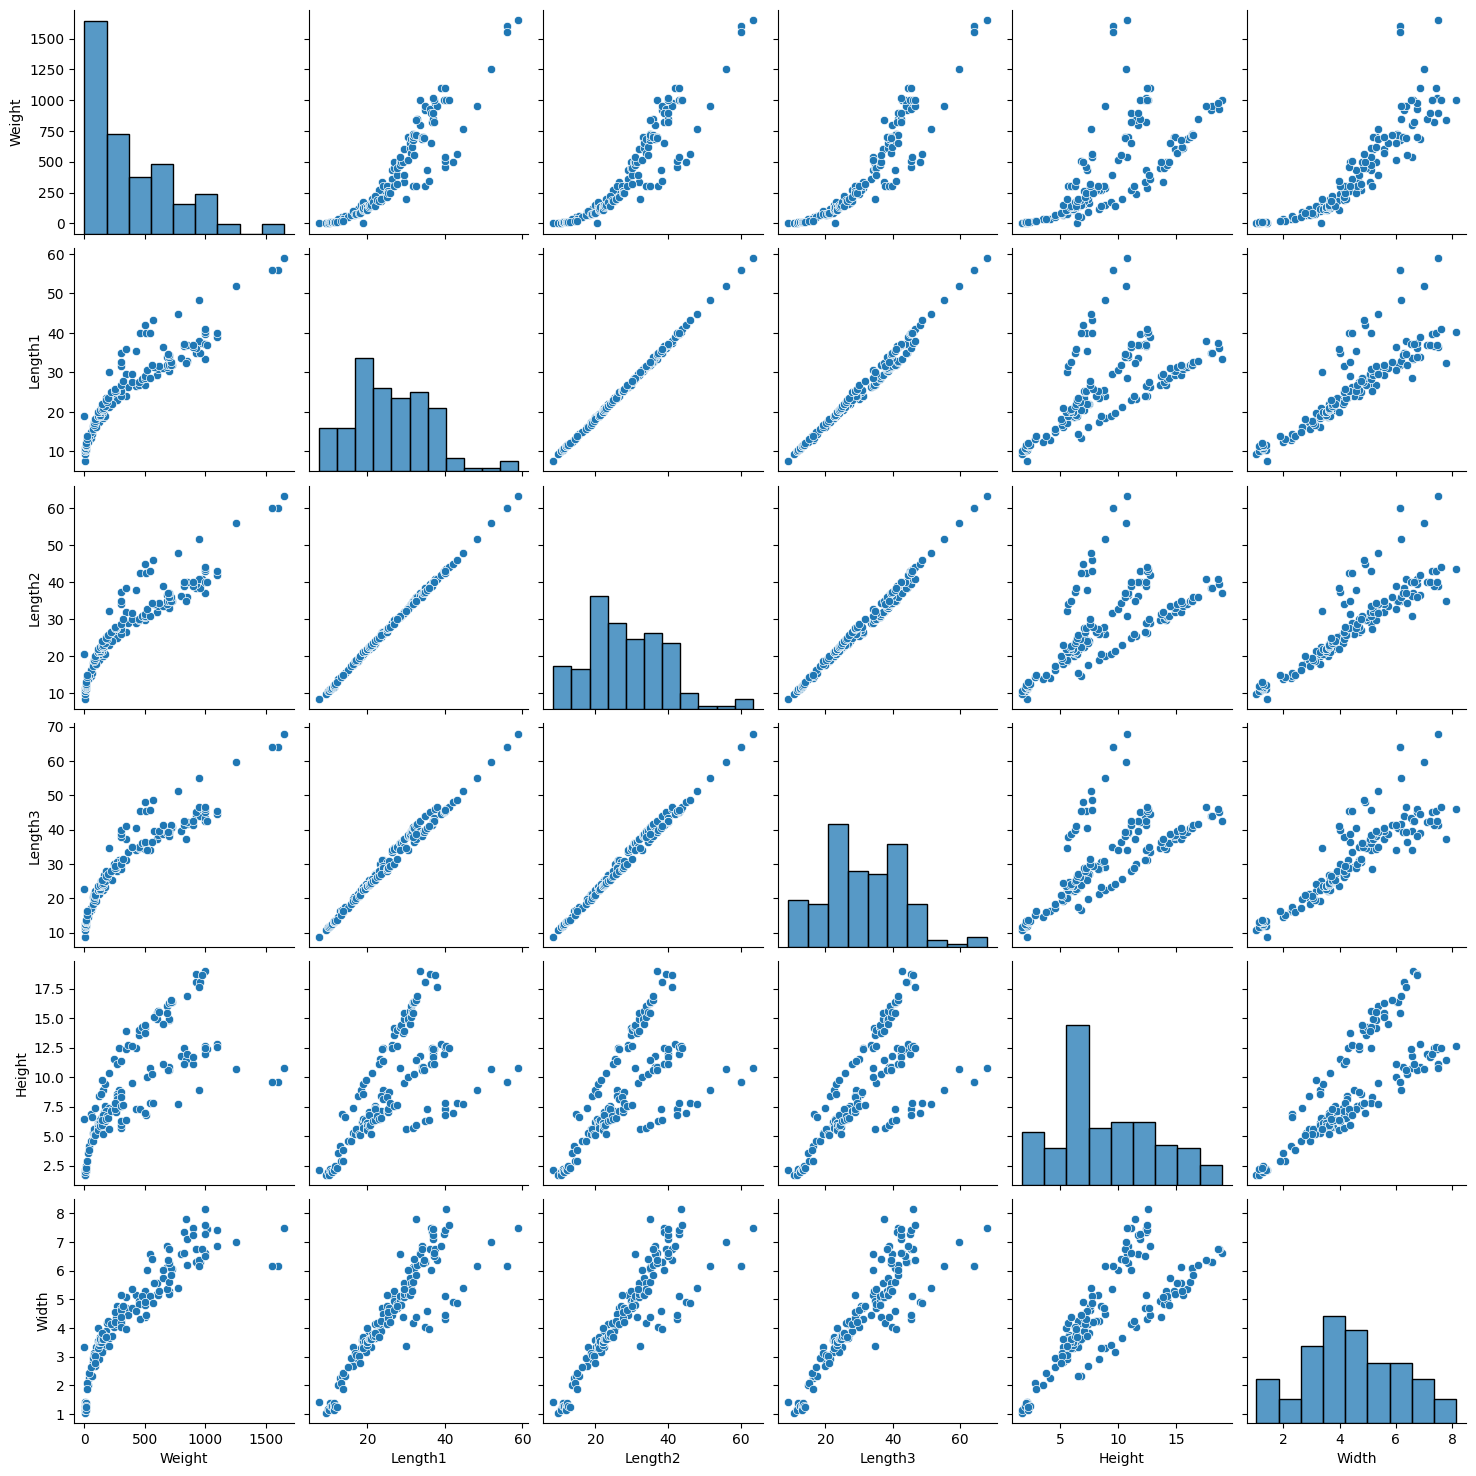

In [10]:
# in muti-variant, to chexk scatter(whether linear or non-linear) of all features together
sns.pairplot(df)
plt.show()


In [17]:
df = pd.get_dummies(df, columns=['Species'], drop_first=True)

In [18]:
x = df.drop(['Weight'], axis=1)
y = df.Weight

In [19]:
# Data Splitting
X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)
print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 127
Testing Samples: 32


In [20]:
# Model Training
lr = linear_model.LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [21]:
# Prediction
y_pred = lr.predict(X_test)


In [22]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("\nMAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)



MAE : 65.30005153357372
MSE : 7007.383189853901
RMSE: 83.71011402365846
R2 Score: 0.9507352480054515


In [23]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

print(comparison.head(10))

     Actual    Predicted
78     78.0    18.738254
155    13.4    11.886420
128   200.0   187.711281
55    270.0   332.739895
94    150.0   212.097016
29   1000.0   757.761616
147     7.0   -61.143019
51    180.0   255.772525
98    188.0   260.494792
141  1250.0  1148.322830


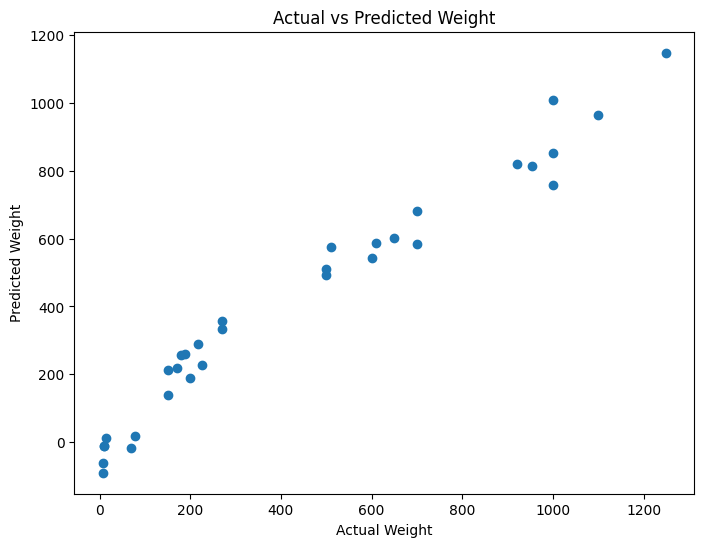

In [ ]:
# visualization
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Weight")
plt.ylabel("Predicted Weight")

plt.title("Actual vs Predicted Weight")

plt.show()

In [24]:
#  MODEL COEFFICIENTS

coef_df = pd.DataFrame({
    "Feature": x.columns,
    "Coefficient": lr.coef_
})

print(coef_df)

print("\nIntercept:")
print(lr.intercept_)


              Feature  Coefficient
0             Length1   -59.139551
1             Length2    55.615294
2             Length3    39.053787
3              Height   -10.730452
4               Width     7.226213
5      Species_Parkki   139.562426
6       Species_Perch    74.670800
7        Species_Pike  -331.375484
8       Species_Roach    34.994835
9       Species_Smelt   330.686475
10  Species_Whitefish    47.641524

Intercept:
-826.8181491630814


In [25]:
# Trying other models
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor

In [31]:
models = {
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "K-Nearest Neighbors": KNeighborsRegressor(),
}

# ---- Step 1: Empty Lists ----
model_names = []
mse_scores = []
r2_scores = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    model_names.append(name)
    mse_scores.append(mse)
    r2_scores.append(r2)

    print(f"{name} - MSE: {mse:.2f}, R²: {r2:.4f}")

#comparison table
comparison_df = pd.DataFrame({
    'Model': model_names,    # Poori list
    'MSE': mse_scores,       # Poori list
    'R² Score': r2_scores    # Poori list
})

# Sorting
comparison_df = comparison_df.sort_values('R² Score', ascending=False)

print("\n" + "="*50)
print("MODEL COMPARISON TABLE:")
print("="*50)
print(comparison_df.to_string(index=False))

Decision Tree - MSE: 6714.61, R²: 0.9528
Random Forest - MSE: 4560.18, R²: 0.9679
K-Nearest Neighbors - MSE: 4854.07, R²: 0.9659

MODEL COMPARISON TABLE:
              Model         MSE  R² Score
      Random Forest 4560.181234  0.967940
K-Nearest Neighbors 4854.068913  0.965874
      Decision Tree 6714.605625  0.952794


In [33]:
# Based on comparison, it is clear that random forest is best, as its R2 score is highest of all, and MSE is lowest of all

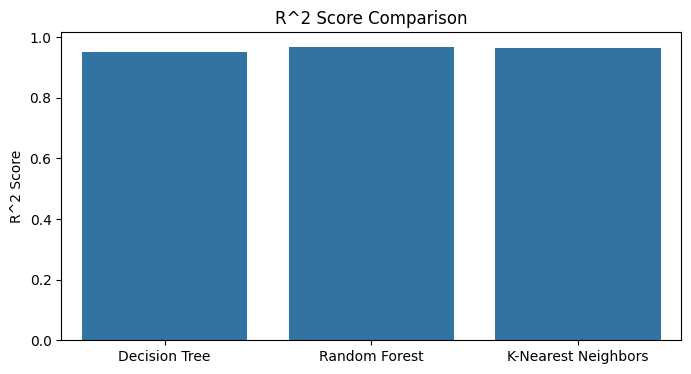

In [32]:
results = []
for name, model in models.items():
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    results.append((name, r2))

model_names, r2_scores = zip(*results)
plt.figure(figsize=(8, 4))
sns.barplot(x=list(model_names), y=list(r2_scores))
plt.title("R^2 Score Comparison")
plt.ylabel("R^2 Score")
plt.show()